# Step 3: ML Model Comparison
Goal: Find the best classifier across all 16 users using TimeSeriesSplit and Optuna.

In [1]:
import os
import glob
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna

warnings.filterwarnings('ignore')
base_dir = '/home/fallen/Projects/Main_Project/research/results'
users = [f'p{i:02d}' for i in range(1, 17)]

def load_user_data(user_id):
    path = os.path.join(base_dir, f'features_{user_id}.csv')
    if not os.path.exists(path):
        return None, None
    df = pd.read_csv(path)
    if 'mood_class' not in df.columns:
        return None, None
        
    X = df.drop(columns=['Date', 'mood', 'mood_class', 'effective_time_frame'], errors='ignore')
    X = X.select_dtypes(include=[np.number])
    y = df['mood_class']
    
    from sklearn.preprocessing import LabelEncoder
    y_mapped = pd.Series(LabelEncoder().fit_transform(y), index=y.index)
    return X, y_mapped

In [2]:
results = []
best_models = {}

f1_macro = make_scorer(f1_score, average='macro', zero_division=0)

def optimize_user(user_id, X, y):
    def objective(trial):
        model_name = trial.suggest_categorical('model', ['RandomForest', 'XGBoost', 'LightGBM', 'LogisticRegression', 'SVM', 'KNN'])
        
        if model_name == 'RandomForest':
            params = {
                'n_estimators': trial.suggest_int('rf_n_estimators', 50, 200),
                'max_depth': trial.suggest_int('rf_max_depth', 2, 10),
                'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 10)
            }
            model = RandomForestClassifier(**params, random_state=42)
        elif model_name == 'XGBoost':
            params = {
                'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 200),
                'max_depth': trial.suggest_int('xgb_max_depth', 2, 6),
                'learning_rate': trial.suggest_float('xgb_lr', 1e-3, 0.3, log=True)
            }
            model = XGBClassifier(**params, random_state=42, eval_metric='mlogloss')
        elif model_name == 'LightGBM':
            params = {
                'n_estimators': trial.suggest_int('lgb_n_estimators', 50, 200),
                'max_depth': trial.suggest_int('lgb_max_depth', 2, 6),
                'learning_rate': trial.suggest_float('lgb_lr', 1e-3, 0.3, log=True),
                'verbose': -1
            }
            model = LGBMClassifier(**params, random_state=42)
        elif model_name == 'LogisticRegression':
            params = {
                'C': trial.suggest_float('lr_c', 1e-3, 10.0, log=True)
            }
            model = LogisticRegression(**params, max_iter=1000, random_state=42)
        elif model_name == 'SVM':
            params = {
                'C': trial.suggest_float('svm_c', 1e-3, 10.0, log=True),
                'gamma': trial.suggest_categorical('svm_gamma', ['scale', 'auto'])
            }
            model = SVC(**params, random_state=42)
        else: # KNN
            params = {
                'n_neighbors': trial.suggest_int('knn_n_neighbors', 3, 11)
            }
            model = KNeighborsClassifier(**params)
            
        tscv = TimeSeriesSplit(n_splits=3)
        try:
            scores = cross_val_score(model, X, y, cv=tscv, scoring=f1_macro, error_score='raise')
            return scores.mean()
        except Exception:
            return 0.0

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=30)
    
    best_params = study.best_params
    best_model_name = best_params['model']
    
    clean_params = {}
    if best_model_name == 'LogisticRegression':
         clean_params = {k.split('_', 1)[1]: v for k, v in best_params.items() if k.startswith('lr_')}
    elif best_model_name == 'RandomForest':
         clean_params = {k.split('_', 1)[1]: v for k, v in best_params.items() if k.startswith('rf_')}
    elif best_model_name == 'XGBoost':
         clean_params = {k.split('_', 1)[1]: v for k, v in best_params.items() if k.startswith('xgb_')}
    elif best_model_name == 'LightGBM':
         clean_params = {k.split('_', 1)[1]: v for k, v in best_params.items() if k.startswith('lgb_')}
    elif best_model_name == 'SVM':
         clean_params = {k.split('_', 1)[1]: v for k, v in best_params.items() if k.startswith('svm_')}
    elif best_model_name == 'KNN':
         clean_params = {k.split('_', 1)[1]: v for k, v in best_params.items() if k.startswith('knn_')}

    with open(f'/home/fallen/Projects/Main_Project/research/results/best_params_{user_id}.json', 'w') as f:
        json.dump({'model': best_model_name, 'params': clean_params}, f, indent=2)
        
    return best_model_name, study.best_value

for user in users:
    X, y = load_user_data(user)
    if X is not None and len(X) > 10:
        best_name, best_score = optimize_user(user, X, y)
        results.append({'User': user, 'Best Model': best_name, 'Macro F1': best_score})
        print(f"{user} -> {best_name} (F1: {best_score:.3f})")

p01 -> SVM (F1: 0.654)
p02 -> RandomForest (F1: 1.000)
p03 -> LightGBM (F1: 0.653)
p04 -> LightGBM (F1: 0.429)
p05 -> XGBoost (F1: 0.712)
p06 -> LightGBM (F1: 1.000)
p07 -> LogisticRegression (F1: 0.737)
p08 -> RandomForest (F1: 0.504)
p09 -> XGBoost (F1: 0.649)
p10 -> XGBoost (F1: 0.598)
p11 -> SVM (F1: 0.830)
p12 -> LightGBM (F1: 0.829)
p13 -> LogisticRegression (F1: 0.476)
p14 -> RandomForest (F1: 1.000)
p15 -> KNN (F1: 0.602)
p16 -> LightGBM (F1: 0.483)


Saved model_comparison_bar.png


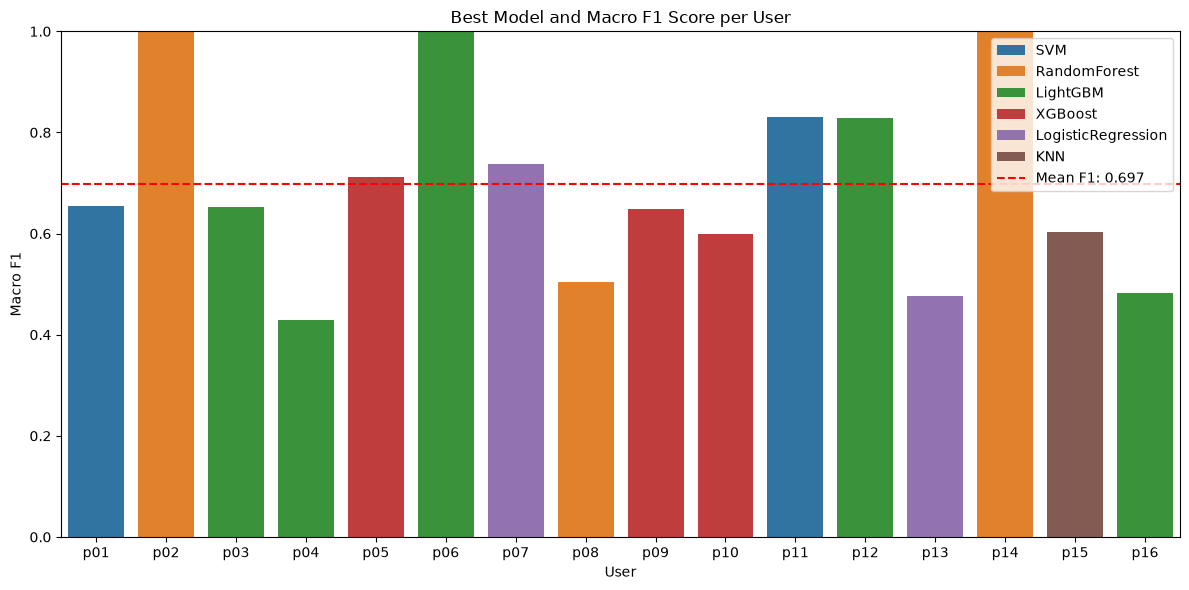

In [3]:
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(base_dir, 'model_comparison.csv'), index=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='User', y='Macro F1', hue='Best Model', dodge=False)
plt.title('Best Model and Macro F1 Score per User')
plt.ylim(0, 1)
plt.axhline(y=results_df['Macro F1'].mean(), color='r', linestyle='--', label=f"Mean F1: {results_df['Macro F1'].mean():.3f}")
plt.legend()
plt.tight_layout()
plt.savefig('/home/fallen/Projects/Main_Project/research/figures/model_comparison_bar.png')
print("Saved model_comparison_bar.png")